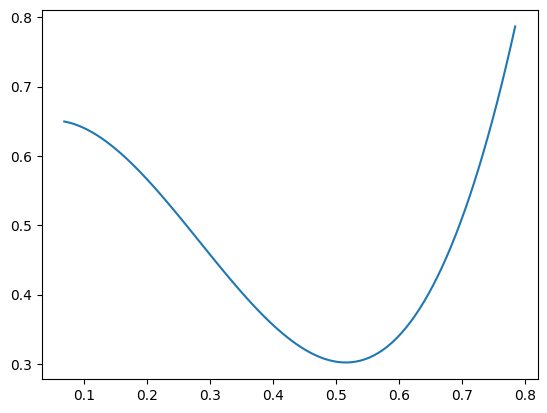

In [13]:
# Import required libraries NumPy, polynomial and matplotlib
import numpy as np
import matplotlib.pyplot as plt
# Generate two random vectors
v1=np.random.rand(10)
v2=np.random.rand(10)
# Creates a sequence of equally separated values
sequence = np.linspace(v1.min(),v1.max(), num=len(v1)*10)
# Fit the data to polynomial fit data with 4 degrees of the polynomial
coefs = np.polyfit(v1, v2, 3)
# Evaluate polynomial on given sequence
polynomial_sequence = np.polyval(coefs,sequence)
# Plot the polynomial curve
plt.plot(sequence, polynomial_sequence)
# Show plot
plt.show()


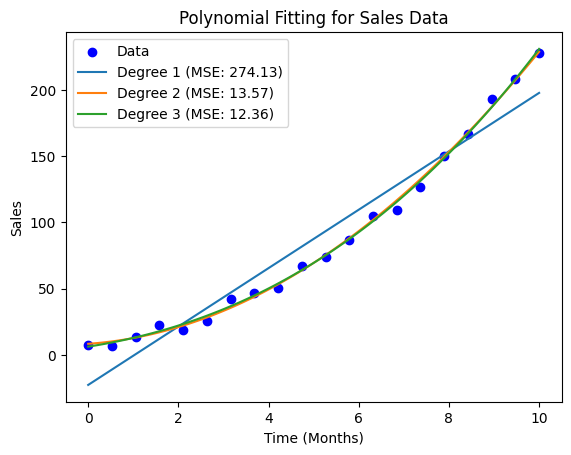

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Simulate sales data: quadratic trend with noise
np.random.seed(42)
x = np.linspace(0, 10, 20)
y = 2 * x**2 + 3 * x + 5 + np.random.normal(0, 5, 20)  # Quadratic with noise

# Fit polynomials of degrees 1, 2, 3
degrees = [1, 2, 3]
sequence = np.linspace(0, 10, 100)
plt.scatter(x, y, color='blue', label='Data')

for deg in degrees:
    coefs = np.polyfit(x, y, deg)
    y_pred = np.polyval(coefs, sequence)
    mse = mean_squared_error(y, np.polyval(coefs, x))
    plt.plot(sequence, y_pred, label=f'Degree {deg} (MSE: {mse:.2f})')

plt.xlabel('Time (Months)')
plt.ylabel('Sales')
plt.title('Polynomial Fitting for Sales Data')
plt.legend()
plt.show()


In [15]:
# Import numpy
import numpy as np
# Create matrix using NumPy
mat = np.mat([[2,4],[5,7]])
print("Matrix:\\n", mat)
# Calculate determinant
print("Determinant:", np.linalg.det(mat))


AttributeError: `np.mat` was removed in the NumPy 2.0 release. Use `np.asmatrix` instead.

In [ ]:
import numpy as np
import pandas as pd

# Simulate stock returns for 3 assets
np.random.seed(42)
returns = np.random.normal(0, 0.01, (100, 3))  # 100 days, 3 assets
cov_matrix = np.cov(returns, rowvar=False)

# Compute determinant
det = np.linalg.det(cov_matrix)
print("Covariance Matrix:\\n", cov_matrix)
print("Determinant:", det)

# Check if invertible
if np.abs(det) > 1e-10:
    print("Matrix is invertible (non-singular).")
else:
    print("Matrix is singular or near-singular.")


In [ ]:
import numpy as np
import pandas as pd
from numpy.linalg import inv

# Simulate house price data
np.random.seed(42)
size = np.random.normal(2000, 500, 100)
bedrooms = np.random.randint(1, 5, 100)
price = 100000 + 150 * size + 20000 * bedrooms + np.random.normal(0, 10000, 100)

# Create design matrix X (with bias term)
X = np.vstack([np.ones(100), size, bedrooms]).T
y = price

# Solve normal equations: beta = (X^T X)^(-1) X^T y
beta = inv(X.T @ X) @ X.T @ y
print("Coefficients (bias, size, bedrooms):", beta)

# Predict prices
y_pred = X @ beta
print("MSE:", mean_squared_error(y, y_pred))


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Simulate points in a 2x2 square
np.random.seed(42)
n = 10000
points = np.random.random((n, 2)) * 2 - 1  # [-1, 1] range

# Check if points lie inside unit circle
inside_circle = np.sum(points**2, axis=1) <= 1
pi_estimate = 4 * np.mean(inside_circle)
print("Estimated π:", pi_estimate)

# Plot
plt.scatter(points[inside_circle, 0], points[inside_circle, 1], c='b', s=1, label='Inside')
plt.scatter(points[~inside_circle, 0], points[~inside_circle, 1], c='r', s=1, label='Outside')
plt.gca().set_aspect('equal')
plt.legend()
plt.title(f"Monte Carlo π Estimation: {pi_estimate:.4f}")
plt.show()


In [ ]:
# Import required library
import numpy as np
import matplotlib.pyplot as plt
sample_size = 225000
# Generate random values sample using normal distribution
sample = np.random.normal(size=sample_size)
# Create Histogram
n, bins, patch_list = plt.hist(sample, int(np.sqrt(sample_size)), density=True)
# Set parameters
mu, sigma = 0, 1
x = bins
y = 1/(sigma * np.sqrt(2 * np.pi)) * np.exp( - (bins - mu)**2 / (2 * sigma**2) )
# Plot line plot (or bell curve)
plt.plot(x, y, color='red', lw=2)
plt.show()


In [ ]:
# Import required library
import numpy as np
from skimage.data import astronaut # Import astronaut image from scikit-image
import matplotlib.pyplot as plt

# Load the astronaut image
face_image = astronaut()

mask_random_array = np.random.randint(0, 3, size=face_image.shape)
fig, ax = plt.subplots(nrows=2, ncols=2)

# Display the Original Image
plt.subplot(2,2,1)
plt.imshow(face_image)
plt.title("Original Image")
plt.axis('off')

# Display masked array
masked_array = np.ma.array(face_image, mask=mask_random_array)
plt.subplot(2,2,2)
plt.title("Masked Array")
plt.imshow(masked_array)
plt.axis('off')

# Log operation on original image
plt.subplot(2,2,3)
plt.title("Log Operation on Original")
plt.imshow(np.ma.log(face_image).astype('uint8'))
plt.axis('off')

# Log operation on masked array
plt.subplot(2,2,4)
plt.title("Log Operation on Masked")
plt.imshow(np.ma.log(masked_array).astype('uint8'))
plt.axis('off')

# Display the subplots
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, probplot
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split

# Set seed for reproducibility
np.random.seed(42)

# Generate sales data
sales = np.random.normal(loc=1000, scale=200, size=1000)

# Introduce 10% missing values
mask = np.random.choice([0, 1], size=sales.size, p=[0.9, 0.1])
masked_sales = np.ma.array(sales, mask=mask)

# Normality test
print("Shapiro-Wilk:", shapiro(masked_sales.compressed()))

# Histogram with PDF
plt.figure(figsize=(10, 6))
sns.histplot(masked_sales.compressed(), kde=True, stat='density')
mu, sigma = masked_sales.mean(), masked_sales.std()
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 100)
y = 1/(sigma * np.sqrt(2 * np.pi)) * np.exp(-((x - mu)**2) / (2 * sigma**2))
plt.plot(x, y, 'r-', lw=2, label='Theoretical PDF')
plt.title("Sales Data Distribution")
plt.legend()
plt.show()

# Q-Q plot
plt.figure(figsize=(6, 6))
probplot(masked_sales.compressed(), dist="norm", plot=plt)
plt.title("Q-Q Plot for Sales Data")
plt.show()

# Gaussian Naive Bayes (example with synthetic labels)
labels = (sales > 1200).astype(int)  # High-revenue days
X_train, X_test, y_train, y_test = train_test_split(sales.reshape(-1, 1), labels, test_size=0.2)
model = GaussianNB()
model.fit(X_train, y_train)
print("Model Accuracy:", model.score(X_test, y_test))
